# Crop Yield Prediction: Regression Model Implementation and Comparison

In [6]:
# ==== Setup and Library Imports ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Set plotting style
sns.set(style="whitegrid")
RANDOM_STATE = 42

# List to store results
model_results = []

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
# ==== Load and Preprocess Dataset ====
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

df = pd.read_csv('crop-yield.csv')

# Identify Categorical and Numerical columns
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(exclude=['object']).drop('Crop_Yield_ton_per_hectare', axis=1).columns

# Label Encoding for categorical features
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Min-Max Scaling for numerical features
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Separate Features and Target
X = df.drop('Crop_Yield_ton_per_hectare', axis=1)
y = df['Crop_Yield_ton_per_hectare']

# Splitting Data (80/20 as requested)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

print(f"Dataset Preprocessed. Training set: {X_train.shape}, Test set: {X_test.shape}")
display(df.head())

Dataset Preprocessed. Training set: (8000, 19), Test set: (2000, 19)


,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Crop_Type,Irrigation_Type,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
0,0.684564,0.559524,0.015504,0.455882,0.895779,0,0.100000,0.432333,0.398133,0.402224,0.532857,0.880000,0,0.016371,1,1,0,0.563802,0.9344,11.42
1,0.617450,0.666667,0.356589,0.347059,0.210842,2,0.269231,0.233333,0.781761,0.656918,0.750000,0.682353,2,0.709868,1,2,0,0.350186,0.1768,23.19
2,0.093960,0.238095,0.651163,0.961765,0.217443,2,0.376923,0.517333,0.246249,0.766642,0.642857,0.860588,2,0.850387,1,3,2,0.429783,0.2516,7.94
3,0.711409,0.964286,0.720930,0.008824,0.559512,3,0.115385,0.286333,0.031344,0.122663,0.678571,0.264118,1,0.347885,0,4,2,0.738102,0.1088,72.53
4,0.476510,0.226190,0.170543,0.305882,0.660332,3,0.300000,0.424667,0.271090,0.073150,0.571429,0.378824,0,0.519782,2,5,2,0.043765,0.6148,6.72


In [8]:
# ==== Helper Function for Evaluation and Plotting ====
def evaluate(model, model_name, X_test, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"--- {model_name} Evaluation ---")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}\n")

    # Store results
    model_results.append({
        'Model': model_name,
        'R2 Score': r2,
        'MAE': mae,
        'RMSE': rmse
    })

In [9]:
# ==== Linear Regression ====
# Baseline model
print("Training Linear Regression...")
lin_reg = LinearRegression(n_jobs=-1)
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

evaluate(lin_reg, "Linear Regression", X_test, y_test, y_pred_lin)

Training Linear Regression...
--- Linear Regression Evaluation ---
R² Score: 0.1339
MAE: 16.5654
RMSE: 22.4683



In [10]:
# ==== Ridge Regression ====
print("Training Ridge Regression (GridSearchCV)...")
ridge = Ridge(random_state=RANDOM_STATE)
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
grid_ridge = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2', n_jobs=-1)
grid_ridge.fit(X_train, y_train)

y_pred_ridge = grid_ridge.predict(X_test)
evaluate(grid_ridge.best_estimator_, "Ridge Regression", X_test, y_test, y_pred_ridge)

Training Ridge Regression (GridSearchCV)...
--- Ridge Regression Evaluation ---
R² Score: 0.1346
MAE: 16.5609
RMSE: 22.4598



In [11]:
# ==== Lasso Regression ====
print("Training Lasso Regression (GridSearchCV)...")
lasso = Lasso(random_state=RANDOM_STATE)
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
grid_lasso = GridSearchCV(lasso, lasso_params, cv=5, scoring='r2', n_jobs=-1)
grid_lasso.fit(X_train, y_train)

y_pred_lasso = grid_lasso.predict(X_test)
evaluate(grid_lasso.best_estimator_, "Lasso Regression", X_test, y_test, y_pred_lasso)

Training Lasso Regression (GridSearchCV)...
--- Lasso Regression Evaluation ---
R² Score: 0.1342
MAE: 16.5628
RMSE: 22.4651



In [12]:
# ==== ElasticNet ====
print("Training ElasticNet (GridSearchCV)...")
elastic = ElasticNet(random_state=RANDOM_STATE)
elastic_params = {'alpha': [0.01, 0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8]}
grid_elastic = GridSearchCV(elastic, elastic_params, cv=5, scoring='r2', n_jobs=-1)
grid_elastic.fit(X_train, y_train)

y_pred_elastic = grid_elastic.predict(X_test)
evaluate(grid_elastic.best_estimator_, "ElasticNet", X_test, y_test, y_pred_elastic)

Training ElasticNet (GridSearchCV)...
--- ElasticNet Evaluation ---
R² Score: 0.1346
MAE: 16.5644
RMSE: 22.4591



In [13]:
# ==== Decision Tree Regressor ====
print("Training Decision Tree (CV for max_depth)...")
dt = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_params = {'max_depth': [3, 5, 7, 10, 12, 15]}
grid_dt = GridSearchCV(dt, dt_params, cv=5, scoring='r2', n_jobs=-1)
grid_dt.fit(X_train, y_train)

y_pred_dt = grid_dt.predict(X_test)
evaluate(grid_dt.best_estimator_, "Decision Tree Regressor", X_test, y_test, y_pred_dt)

Training Decision Tree (CV for max_depth)...
--- Decision Tree Regressor Evaluation ---
R² Score: 0.9970
MAE: 1.0610
RMSE: 1.3115



In [14]:
# ==== Random Forest Regressor ====
print("Training Random Forest...")
rf_reg = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

evaluate(rf_reg, "Random Forest Regressor", X_test, y_test, y_pred_rf)

Training Random Forest...
--- Random Forest Regressor Evaluation ---
R² Score: 0.9978
MAE: 0.9068
RMSE: 1.1312



In [15]:
# ==== Gradient Boosting Regressor ====
print("Training Gradient Boosting...")
gb_reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE)
gb_reg.fit(X_train, y_train)
y_pred_gb = gb_reg.predict(X_test)

evaluate(gb_reg, "Gradient Boosting Regressor", X_test, y_test, y_pred_gb)

Training Gradient Boosting...
--- Gradient Boosting Regressor Evaluation ---
R² Score: 0.9981
MAE: 0.8345
RMSE: 1.0435



In [16]:
# ==== Support Vector Regressor (SVR) ====
print("Training SVR (GridSearchCV)...")
svr = SVR(kernel='rbf')
svr_params = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.2],
    'gamma': ['scale', 'auto']
}
grid_svr = GridSearchCV(svr, svr_params, cv=5, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train, y_train)

y_pred_svr = grid_svr.predict(X_test)
evaluate(grid_svr.best_estimator_, "SVR", X_test, y_test, y_pred_svr)

Training SVR (GridSearchCV)...
--- SVR Evaluation ---
R² Score: 0.3786
MAE: 11.6125
RMSE: 19.0311



In [17]:
# ==== KNN Regressor ====
print("Tuning K for KNN Regressor...")
k_range = range(1, 21)
knn_scores = []
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='r2')
    knn_scores.append(scores.mean())

optimal_k = k_range[np.argmax(knn_scores)]
print(f"Optimal K found: {optimal_k}")

knn_final = KNeighborsRegressor(n_neighbors=optimal_k)
knn_final.fit(X_train, y_train)
y_pred_knn = knn_final.predict(X_test)

evaluate(knn_final, "KNN Regressor", X_test, y_test, y_pred_knn)

Tuning K for KNN Regressor...
Optimal K found: 6
--- KNN Regressor Evaluation ---
R² Score: 0.8953
MAE: 4.5738
RMSE: 7.8104



In [18]:
# ==== XGBoost Regressor ====
print("Training XGBoost...")
xgb_reg = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
xgb_reg.fit(X_train, y_train)
y_pred_xgb = xgb_reg.predict(X_test)

evaluate(xgb_reg, "XGBoost Regressor", X_test, y_test, y_pred_xgb)

Training XGBoost...
--- XGBoost Regressor Evaluation ---
R² Score: 0.9981
MAE: 0.8499
RMSE: 1.0649



--- Model Comparison Table ---


,Model,R2 Score,MAE,RMSE
6,Gradient Boosting Regressor,0.998132,0.834525,1.043538
9,XGBoost Regressor,0.998054,0.849864,1.064924
5,Random Forest Regressor,0.997805,0.906822,1.131175
4,Decision Tree Regressor,0.997049,1.061006,1.311494
8,KNN Regressor,0.895343,4.573835,7.810397
7,SVR,0.378633,11.612461,19.031052
3,ElasticNet,0.134616,16.564412,22.459144
1,Ridge Regression,0.134563,16.560909,22.459830
2,Lasso Regression,0.134155,16.562772,22.465125
0,Linear Regression,0.133909,16.565416,22.468317


/tmp/ipykernel_9998/3315498625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score', y='Model', data=results_df, palette='magma')


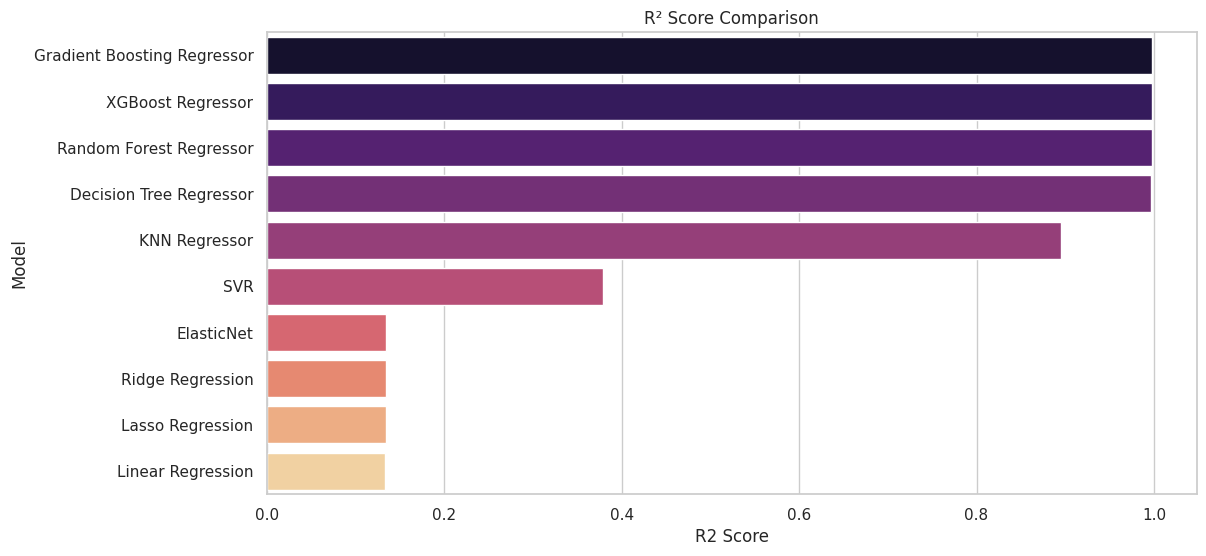

The best performing model is: Gradient Boosting Regressor


In [19]:
# ==== Final Comparison ====
results_df = pd.DataFrame(model_results).sort_values(by='R2 Score', ascending=False)

print("--- Model Comparison Table ---")
display(results_df)

# Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x='R2 Score', y='Model', data=results_df, palette='magma')
plt.title('R² Score Comparison')
plt.show()

# Best Model
best_model_name = results_df.iloc[0]['Model']
print(f"The best performing model is: {best_model_name}")

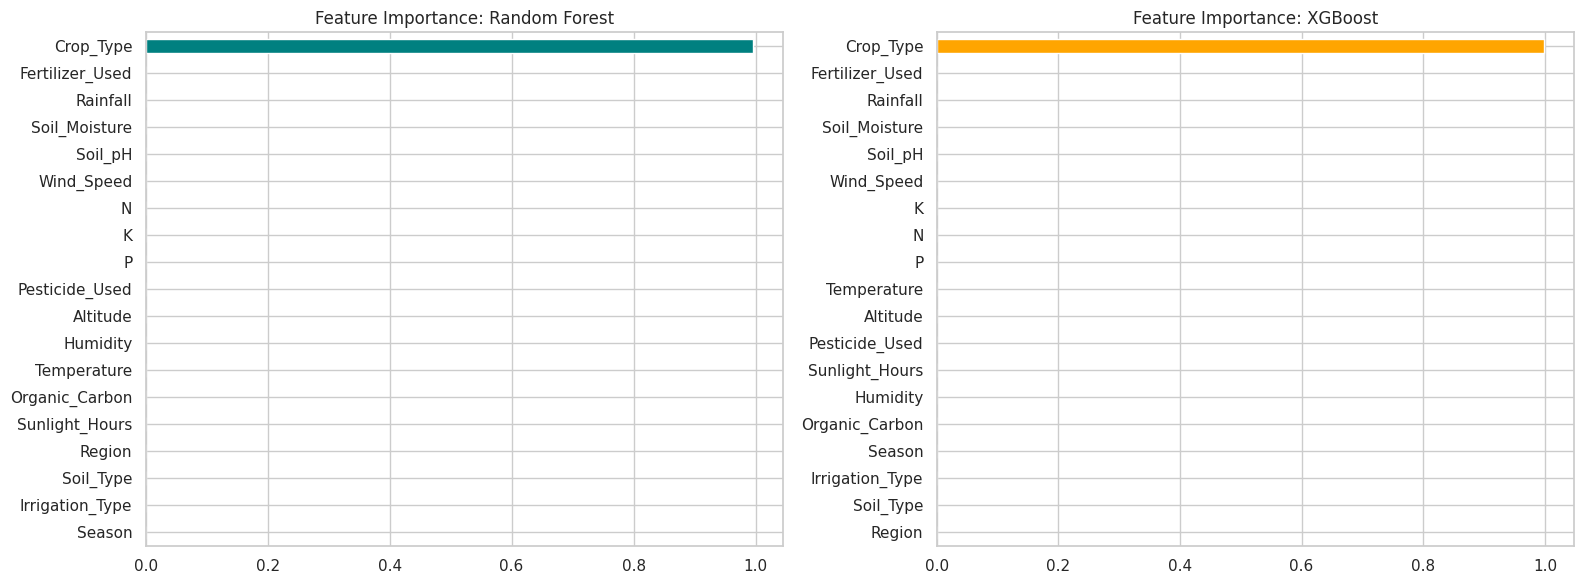

In [20]:
# ==== Feature Importance (RF & XGB) ====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values()
rf_importances.plot(kind='barh', ax=ax1, color='teal')
ax1.set_title('Feature Importance: Random Forest')

# XGBoost
xgb_importances = pd.Series(xgb_reg.feature_importances_, index=X.columns).sort_values()
xgb_importances.plot(kind='barh', ax=ax2, color='orange')
ax2.set_title('Feature Importance: XGBoost')

plt.tight_layout()
plt.show()